# 05 — Event Study

Stage 11's event-window methodology (`src/analytics/event_study.py`), demonstrated live on the real "DeepSeek shock" event — see `EVENT_STUDY.md` for the full catalog and the independent real-world verification this event provides.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd
from src.analytics.event_study import abnormal_return_window
from src.analytics.market_stats import add_returns
from src.config import RAW_DIR

def load_returns(market_id):
    df = pd.read_parquet(RAW_DIR / 'market_prices' / f'{market_id}.parquet')[['date', 'close']]
    return add_returns(df)

nvda = load_returns('NVDA')
spx = load_returns('SPX')
window = abnormal_return_window(nvda['return_1d'], nvda['date'], spx['return_1d'], spx['date'],
                                 '2025-01-27', window=5)
window

-5    0.021004
-4    0.013888
-3    0.038171
-2   -0.004294
-1   -0.028391
0    -0.155101
1     0.080041
2    -0.036332
3     0.002404
4    -0.031696
5    -0.020791
dtype: float64

## Abnormal return around the event

Text(0, 0.5, 'Abnormal return')

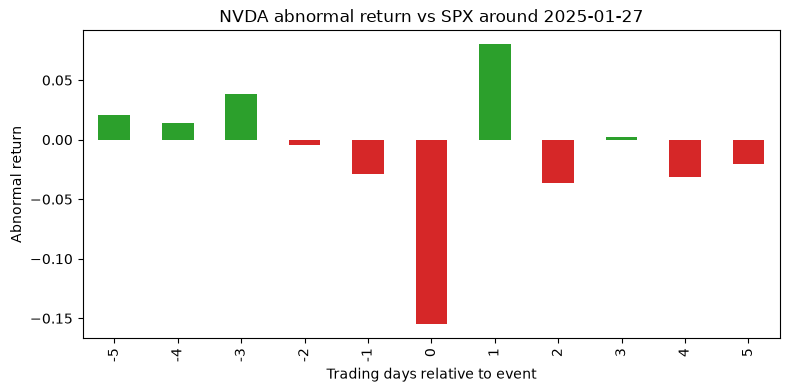

In [2]:
ax = window.plot(kind='bar', figsize=(9, 4), title='NVDA abnormal return vs SPX around 2025-01-27',
                  color=['#d62728' if v < 0 else '#2ca02c' for v in window])
ax.set_xlabel('Trading days relative to event')
ax.set_ylabel('Abnormal return')